# Random Forest Regression

In this section, we apply a Random Forest regression model to predict wine quality and evaluate its performance under different settings.

# Without PCA

We now implement a Random Forest regression model to analyze and predict wine quality and without using the dimension reduction method called PCA (Principal Component Analysis).

## 1. Extraction of the data

We begin by importing the necessary libraries and loading the dataset for analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import seaborn as sns

We first collect our dataset of red wines, and we look at the first data in it.  

In [5]:
red_wine = pd.read_csv("../data/raw/winequality-red.csv", sep=";")
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Preparation features & target variable

Next, we define the input features and the target variable for our model.

In [6]:
# Features (X) and target (y)
X = red_wine.drop("quality", axis=1)
y = red_wine["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3. Train the Random Forest Model

We now train the Random Forest model using the training data so it can learn the relationship between the wine features and their quality.

In [7]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The model has now learned from the data and is ready to make predictions.

### 4. Make the predictions

Next, we use the trained model to predict the quality of wines in the test dataset.

In [8]:
rf_predictions = model.predict(X_test)

These predicted values will allow us to check how accurate the model is.

### 5. Random forest evaluation

We evaluate the model by comparing its predictions with the true values using error metrics.

In [9]:
# Metrics
mse = mean_squared_error(y_test, rf_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Random Forest Performance:
MSE: 0.30123812499999997
RMSE: 0.5488516420673258
R²: 0.5390429623873638


We evaluate the model using:

- MSE: average squared error (lower is better)
- RMSE: error in the same unit as the target (lower is better)
- R²: proportion of variance explained (closer to 1 is better)

The Random Forest model achieves an MSE of 0.301 and an RMSE of 0.549, indicating relatively low prediction errors.

The R² score of 0.539 means the model explains about 54% of the variability in wine quality.

### 6. Comparison Dummy model (baseline)

To understand if our model is useful, we compare it to a simple baseline that always predicts the average quality.

In [10]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_predictions = dummy.predict(X_test)

# Metrics
dummy_mse = mean_squared_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test, dummy_predictions)

print("\nDummy Model Performance:")
print("MSE:", dummy_mse)
print("RMSE:", dummy_rmse)
print("R²:", dummy_r2)


Dummy Model Performance:
MSE: 0.6571600689645265
RMSE: 0.81065409945582
R²: -0.005591701339940913


The Dummy model has an RMSE of 0.811 and an R² of -0.006, meaning it performs very poorly and does not capture any relationship in the data.

In contrast, the Random Forest model reduces the RMSE to 0.549 and achieves an R² of 0.539, showing a clear improvement.

This means the Random Forest model makes more accurate predictions and is able to explain a significant part of the variation in wine quality, unlike the dummy model which only predicts the average.

# With PCA

We apply PCA to reduce the number of features while keeping most of the important information.

#### Libraries

We load the libraries that contain the PCA method and the method that allow us to scale our data.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Because we saw that the different features are on different scales, and because the PCA methods is based on the measure of variance, we need to standardize the data before applying the PCA

In [12]:
# Scale the data before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # keep 95% of the variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

The number of features is reduced, while most of the data variability is preserved. We now have 9 features (compared to 11 at first), explaining 98% of the information contained in the data (see below). Plus, now the features are now independent from one another.

In [13]:
print("Original number of features:", X_train.shape[1])
print("Number of principal components:", X_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 11
Number of principal components: 9
Explained variance ratio: [0.2801769  0.17563995 0.13957636 0.11081822 0.09021248 0.05908698
 0.05266627 0.03883888 0.03129468]
Total explained variance: 0.9783107305383208


#### Training of the Random Forest on PCA-transformed data

We train a new Random Forest model using the transformed data from PCA.

In [14]:
# Train Random Forest on PCA-transformed data
rf_pca_model = RandomForestRegressor(random_state=42)
rf_pca_model.fit(X_train_pca, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The model has now learned from the reduced feature set.

#### Predictions of the new model (random forest on Principal components)

We use this new model to predict wine quality on the test data.

In [15]:
# Predict
rf_pca_predictions = rf_pca_model.predict(X_test_pca)

These predictions will be used to evaluate how well this approach works.

#### Assessment of the performance of the new model

We evaluate the performance of the model trained with PCA.

In [16]:
# Metrics
pca_mse = mean_squared_error(y_test, rf_pca_predictions)
pca_rmse = np.sqrt(pca_mse)
pca_r2 = r2_score(y_test, rf_pca_predictions)

print("\nRandom Forest + PCA Performance:")
print("MSE:", pca_mse)
print("RMSE:", pca_rmse)
print("R²:", pca_r2)


Random Forest + PCA Performance:
MSE: 0.318494375
RMSE: 0.5643530588204515
R²: 0.5126373077900148


We can now compare these results with the previous model to see if PCA helped.

In [17]:
# Compare all models
results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Random Forest", "Random Forest + PCA"],
    "MSE": [dummy_mse, mse, pca_mse],
    "RMSE": [dummy_rmse, rmse, pca_rmse],
    "R²": [dummy_r2, r2, pca_r2]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
                 Model       MSE      RMSE        R²
0      Dummy Regressor  0.657160  0.810654 -0.005592
1        Random Forest  0.301238  0.548852  0.539043
2  Random Forest + PCA  0.318494  0.564353  0.512637


We evaluate the models using:

- MSE (Mean Squared Error): measures the average squared difference between predicted and actual values (lower is better)
- RMSE (Root Mean Squared Error): similar to MSE but in the same unit as the target (lower is better)
- R² score: indicates how well the model explains the variance in the data (closer to 1 is better)

The Dummy Regressor performs poorly with an R² of -0.006 and RMSE of 0.811, meaning it does not capture any useful patterns.

The Random Forest model improves performance, with RMSE 0.549 and R² 0.539.

The Random Forest with PCA is slightly worse, with RMSE 0.564 and R² 0.513.

PCA may perform worse because it reduces the feature space by combining variables, which can remove important information that the Random Forest model could otherwise use to capture complex relationships in the data.

# Analysis To understand the limitation of our results of the random forest (without PCA)

The performance of the Random Forest model was evaluated using standard regression metrics and diagnostic plots. The objective of this analysis is not only to assess predictive accuracy, but also to interpret the results in a way that is meaningful for wine quality assessment.

### 1. Overall Model Performance

The model achieves a coefficient of determination (R²) of approximately 0.54, indicating that it explains slightly more than half of the variability in wine quality. The remaining variability is not captured by the model.

From a wine analysis perspective, this result is expected. While physicochemical properties such as acidity, alcohol content, and sulphates influence wine quality, they do not fully represent all aspects involved in wine evaluation. Sensory characteristics such as aroma, complexity, and balance, which are essential in professional tasting, are not included in the dataset. The price might also bring informations.

### 2. Predicted vs Actual Quality

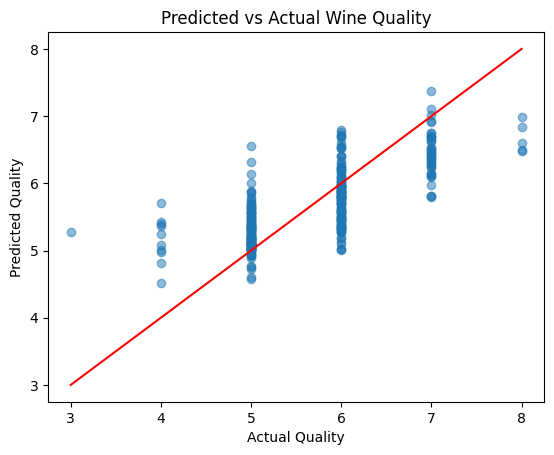

In [29]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Wine Quality")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

The comparison between predicted and actual values shows that the model tends to produce predictions concentrated around the central range of quality scores (between 5 and 6.5). As a result, wines with very low or very high quality scores are not accurately predicted.

This behavior indicates that the model struggles to distinguish extreme cases. In practical terms, it tends to overestimate lower-quality wines and underestimate higher-quality wines.

In the context of wine evaluation, this suggests that the model is less effective at identifying wines with particularly distinctive characteristics, whether positive or negative. Such distinctions often rely on subtle sensory attributes that are not captured by chemical measurements alone.

This might be explained by the fact that most of the data inside the red wine dataset that we use are also around 5-6 of quality. Thus the model has less examples on extreme values of quality, making it harder for it to learn patterns for those.

### 3. Residual Analysis

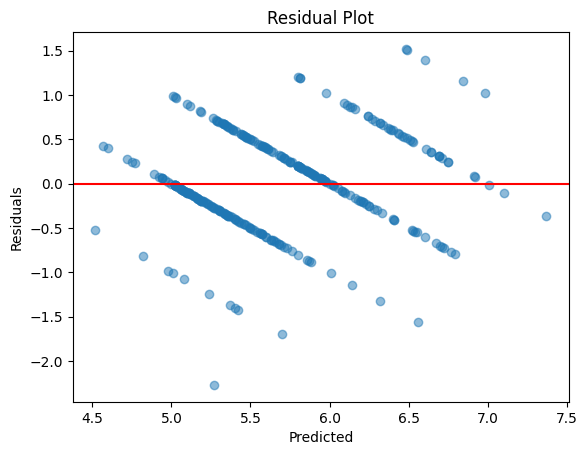

In [30]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The diagonal patterns reflect the discrete nature of wine ratings, while the spread of residuals shows that wines with similar predicted quality can vary significantly in actual quality. This highlights the limitations of relying only on chemical features to evaluate wine.

### 4. Distribution of Errors

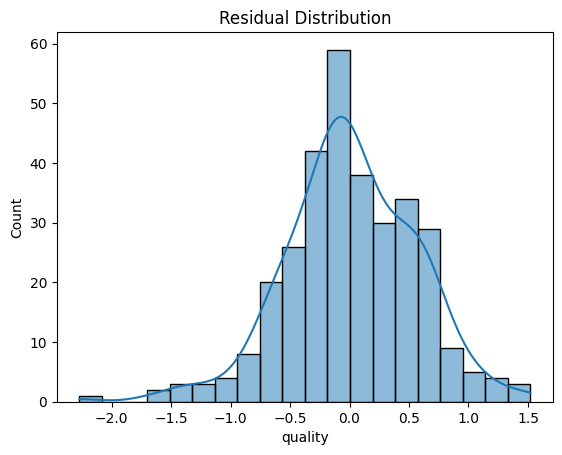

In [27]:
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.show()

The distribution of residuals is centered around zero, indicating that the model is not significantly biased toward over- or under-prediction. However, the relatively wide spread of errors highlights a lack of precision.

In practical terms, this means that while the model provides reasonable average estimates, individual predictions may still deviate notably from actual quality scores.

For wine professionals, this reinforces the idea that predicting quality based solely on chemical composition involves a degree of uncertainty.

### 5. Feature Importance

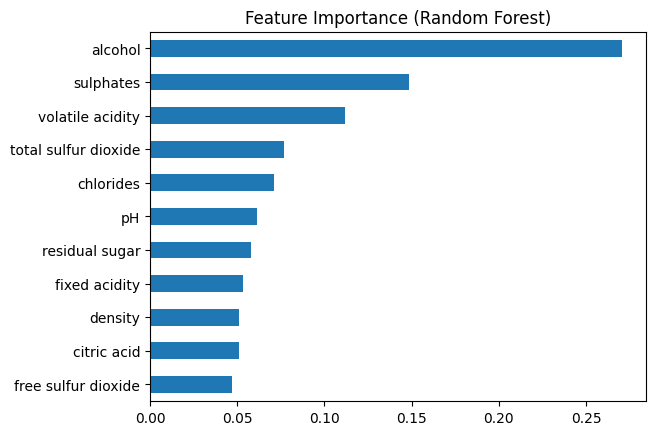

In [28]:
importances = model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance (Random Forest)")
plt.show()

The analysis of feature importance identifies the most influential variables in predicting wine quality.

Alcohol content emerges as the most significant factor, followed by sulphates and volatile acidity. This aligns with established knowledge in oenology. Higher alcohol levels are often associated with fuller-bodied wines, which can positively influence perceived quality. Sulphates contribute to wine stability and preservation, which may enhance overall quality. In contrast, high levels of volatile acidity are generally linked to undesirable flavors, negatively affecting quality.

Other variables, such as pH, density, and residual sugar, show a comparatively lower impact on the model’s predictions.

### 6. Limitations and Implications

Despite the use of a machine learning model, the predictive performance remains moderate. This limitation can be attributed to several factors, including the absence of sensory data, the subjective nature of wine evaluation, and inherent variability in the dataset.

Two wines with similar chemical compositions may still be rated differently due to differences in aroma, texture, or overall balance. These aspects are critical in wine tasting but are not captured in the available features.

# Conclusion

The Random Forest model provides valuable insights into the relationship between chemical properties and wine quality, particularly highlighting the importance of alcohol, sulphates, and acidity.

However, the results also demonstrate that chemical analysis alone is insufficient to fully predict wine quality. The model should therefore be considered as a complementary analytical tool, capable of identifying general trends, rather than a substitute for expert sensory evaluation.